# Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys

from sklearn.linear_model import LinearRegression, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import joblib

# Make src importable
root = Path("..").resolve()
sys.path.append(str(root / "src"))

# Import the cleaned module
from functions import (
    load_data, train_val_split, get_X_y,
    build_preprocessing_pipeline, build_model_pipeline,
    bootstrap_metrics, bootstrap_distributions,
    mrmr_importance_df, evaluate_feature_set,
    bootstrap_eval, tune_model, make_table
)

# Load Data & Split
dev_path = root / "data" / "development_data.csv"
eval_path = root / "data" / "evaluation_data.csv"

dev_df, eval_df = load_data(dev_path, eval_path)
train_df, val_df = train_val_split(dev_df)

# Baseline Models (Task 2)

## Prepare Feature Sets (CpG, Metadata, Both)

In [2]:
# CpG-only
X_train_cpg, y_train, _ = get_X_y(train_df, use_cpg=True, use_metadata=False)
X_val_cpg, y_val, _ = get_X_y(val_df, use_cpg=True, use_metadata=False)

# Metadata-only
X_train_meta, _, _ = get_X_y(train_df, use_cpg=False, use_metadata=True)
X_val_meta, _, _ = get_X_y(val_df, use_cpg=False, use_metadata=True)

# CpG + Metadata
X_train_both, _, _ = get_X_y(train_df, use_cpg=True, use_metadata=True)
X_val_both, _, _ = get_X_y(val_df, use_cpg=True, use_metadata=True)

## Baseline OLS Models

In [3]:
# CpG-only OLS
preprocess_cpg, _, _ = build_preprocessing_pipeline(train_df, use_cpg=True, use_metadata=False)
ols_cpg = build_model_pipeline(preprocess_cpg, LinearRegression())

ols_cpg.fit(X_train_cpg, y_train)
preds_cpg = ols_cpg.predict(X_val_cpg)

metrics_cpg = bootstrap_metrics(y_val, preds_cpg)
metrics_cpg

{'RMSE': (np.float64(4.765305398534447),
  np.float64(3.703510389041239),
  np.float64(5.97773567510866)),
 'MAE': (np.float64(3.5753588879860865),
  np.float64(2.9459813449554613),
  np.float64(4.29195213519001)),
 'R2': (np.float64(0.8905285120236119),
  np.float64(0.8240646329769449),
  np.float64(0.9385161932589059)),
 'R': (np.float64(0.9489439908193938),
  np.float64(0.9161381804108099),
  np.float64(0.9712402350978989))}

In [4]:
# Metadata-only OLS
preprocess_meta, _, _ = build_preprocessing_pipeline(train_df, use_cpg=False, use_metadata=True)
ols_meta = build_model_pipeline(preprocess_meta, LinearRegression())

ols_meta.fit(X_train_meta, y_train)
preds_meta = ols_meta.predict(X_val_meta)

metrics_meta = bootstrap_metrics(y_val, preds_meta)
metrics_meta

{'RMSE': (np.float64(12.851722430751735),
  np.float64(10.798977667875608),
  np.float64(15.293444499778788)),
 'MAE': (np.float64(10.351961130859566),
  np.float64(8.865503270330342),
  np.float64(12.037823547322315)),
 'R2': (np.float64(0.22218505262409738),
  np.float64(0.06638238753226432),
  np.float64(0.357699973604101)),
 'R': (np.float64(0.4817409072928908),
  np.float64(0.32313372230209325),
  np.float64(0.6299816267331374))}

In [5]:
# CpG + Metadata OLS
preprocess_both, _, _ = build_preprocessing_pipeline(train_df, use_cpg=True, use_metadata=True)
ols_both = build_model_pipeline(preprocess_both, LinearRegression())

ols_both.fit(X_train_both, y_train)
preds_both = ols_both.predict(X_val_both)

metrics_both = bootstrap_metrics(y_val, preds_both)
metrics_both

{'RMSE': (np.float64(4.725189563800024),
  np.float64(3.6822284502440876),
  np.float64(5.915314840867261)),
 'MAE': (np.float64(3.5495176673793885),
  np.float64(2.936133102806355),
  np.float64(4.2581258505810275)),
 'R2': (np.float64(0.8924011213503327),
  np.float64(0.8271898471988504),
  np.float64(0.9390750935141988)),
 'R': (np.float64(0.9498037008864769),
  np.float64(0.9172880858434045),
  np.float64(0.9713903284503895))}

## Regression Models (ElasticNet, SVR, BayesianRidge)

In [6]:
preprocess_cpg, _, _ = build_preprocessing_pipeline(train_df, use_cpg=True, use_metadata=False)

In [7]:
# ElasticNet
enet = build_model_pipeline(preprocess_cpg, ElasticNet())
enet.fit(X_train_cpg, y_train)
preds_enet = enet.predict(X_val_cpg)

metrics_enet = bootstrap_metrics(y_val, preds_enet)

In [8]:
# SVR
svr = build_model_pipeline(preprocess_cpg, SVR())
svr.fit(X_train_cpg, y_train)
preds_svr = svr.predict(X_val_cpg)

metrics_svr = bootstrap_metrics(y_val, preds_svr)

In [9]:
# BayesianRidge
br = build_model_pipeline(preprocess_cpg, BayesianRidge())
br.fit(X_train_cpg, y_train)
preds_br = br.predict(X_val_cpg)

metrics_br = bootstrap_metrics(y_val, preds_br)

## Bootstrap Distributions for Boxplots

In [10]:
rmse_cpg, r2_cpg = bootstrap_distributions(y_val.values, preds_cpg)
rmse_meta, r2_meta = bootstrap_distributions(y_val.values, preds_meta)
rmse_both, r2_both = bootstrap_distributions(y_val.values, preds_both)

rmse_enet, r2_enet = bootstrap_distributions(y_val.values, preds_enet)
rmse_svr, r2_svr = bootstrap_distributions(y_val.values, preds_svr)
rmse_br, r2_br = bootstrap_distributions(y_val.values, preds_br)

## Build DataFrame for Plotting

In [11]:
df_boot = pd.DataFrame({
    "RMSE": np.concatenate([rmse_cpg, rmse_meta, rmse_both, rmse_enet, rmse_svr, rmse_br]),
    "R2":   np.concatenate([r2_cpg, r2_meta, r2_both, r2_enet, r2_svr, r2_br]),
    "Model": (
        ["OLS CpG"] * len(rmse_cpg) +
        ["OLS Meta"] * len(rmse_meta) +
        ["OLS Both"] * len(rmse_both) +
        ["ElasticNet"] * len(rmse_enet) +
        ["SVR"] * len(rmse_svr) +
        ["BayesianRidge"] * len(rmse_br)
    )
})

## RMSE & R² Boxplots

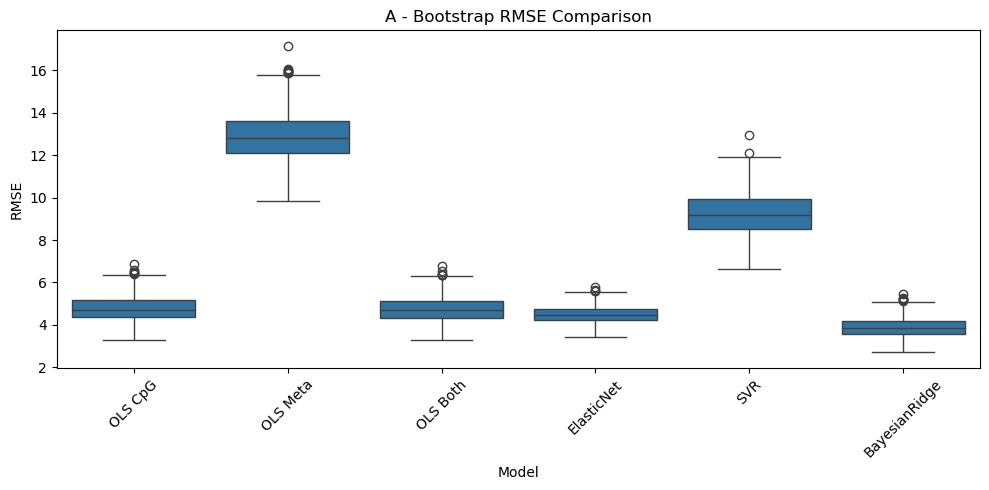

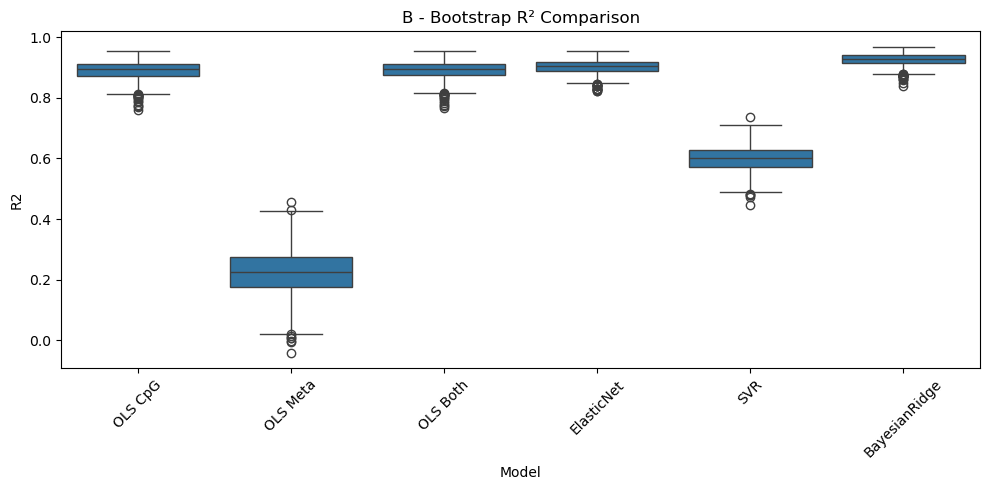

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_boot, x="Model", y="RMSE")
plt.title("A - Bootstrap RMSE Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df_boot, x="Model", y="R2")
plt.title("B - Bootstrap R² Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Mean Statistics Table

In [13]:
results = pd.DataFrame([
    ["OLS", "CpG-only",      *metrics_cpg["RMSE"], metrics_cpg["MAE"][0], metrics_cpg["R2"][0], metrics_cpg["R"][0]],
    ["OLS", "Metadata-only", *metrics_meta["RMSE"], metrics_meta["MAE"][0], metrics_meta["R2"][0], metrics_meta["R"][0]],
    ["OLS", "CpG+metadata",  *metrics_both["RMSE"], metrics_both["MAE"][0], metrics_both["R2"][0], metrics_both["R"][0]],
    ["ElasticNet", "CpG-only", *metrics_enet["RMSE"], metrics_enet["MAE"][0], metrics_enet["R2"][0], metrics_enet["R"][0]],
    ["SVR", "CpG-only",        *metrics_svr["RMSE"],  metrics_svr["MAE"][0], metrics_svr["R2"][0], metrics_svr["R"][0]],
    ["BayesianRidge", "CpG-only", *metrics_br["RMSE"], metrics_br["MAE"][0], metrics_br["R2"][0], metrics_br["R"][0]],
], columns=["Model", "Feature Set", "RMSE", "RMSE CI Low", "RMSE CI High", "MAE", "R2", "Pearson r"])

results

,Model,Feature Set,RMSE,RMSE CI Low,RMSE CI High,MAE,R2,Pearson r
0,OLS,CpG-only,4.765305,3.703510,5.977736,3.575359,0.890529,0.948944
1,OLS,Metadata-only,12.851722,10.798978,15.293444,10.351961,0.222185,0.481741
2,OLS,CpG+metadata,4.725190,3.682228,5.915315,3.549518,0.892401,0.949804
3,ElasticNet,CpG-only,4.488090,3.762313,5.305490,3.466626,0.903212,0.953078
4,SVR,CpG-only,9.245800,7.400020,11.224007,6.789203,0.598716,0.849014
5,BayesianRidge,CpG-only,3.893038,3.109772,4.805108,2.912045,0.926981,0.964271


# Feature Selection (Task 3)

## Stability Selection

In [14]:
X_train_cpg, y_train, cpg_cols = get_X_y(train_df, use_cpg=True, use_metadata=False)
X_train_cpg = pd.DataFrame(X_train_cpg, columns=cpg_cols)
y_train = pd.Series(y_train, index=X_train_cpg.index)

In [15]:
# 1. Extract CpGs directly from train_df
cpg_cols = [c for c in train_df.columns if c.startswith("cg")]
X_train_cpg = train_df[cpg_cols].copy()
y_train = train_df["age"]

# 2. Stability selection parameters
n_subsamples = 50
subsample_frac = 0.8
top_k = 200

feature_counts = pd.Series(0, index=cpg_cols)
rng = np.random.default_rng(42)

# 3. Stability selection loop
for _ in range(n_subsamples):
    subsample_idx = rng.choice(
        X_train_cpg.index,
        size=int(subsample_frac * len(X_train_cpg)),
        replace=False
    )
    X_sub = X_train_cpg.loc[subsample_idx]
    y_sub = y_train.loc[subsample_idx]

    # Spearman correlations
    corrs = X_sub.apply(lambda col: abs(spearmanr(col, y_sub)[0]))
    top_features = corrs.sort_values(ascending=False).head(top_k).index

    feature_counts[top_features] += 1

# 4. Define stable features
stable_threshold = n_subsamples / 2
stable_features = feature_counts[feature_counts > stable_threshold].index.tolist()

print("Number of stable features:", len(stable_features))

# 5. Frequency table (sorted)
freq_df = feature_counts.sort_values(ascending=False)
freq_df.head()

Number of stable features: 200


cg06335143    50
cg16015593    50
cg03032497    50
cg13640414    50
cg16867657    50
dtype: int64

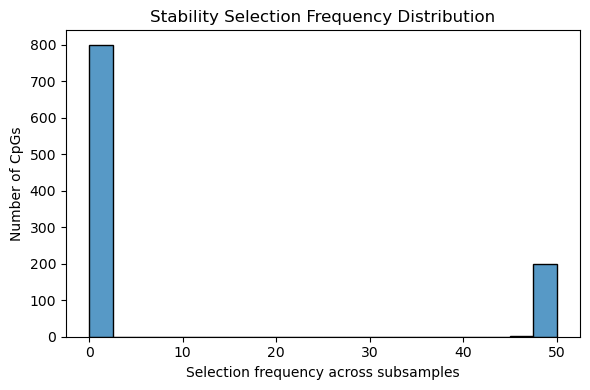

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(feature_counts, bins=20)
plt.xlabel("Selection frequency across subsamples")
plt.ylabel("Number of CpGs")
plt.title("Stability Selection Frequency Distribution")
plt.tight_layout()
plt.show()

In [17]:
metrics_stability = evaluate_feature_set(train_df, val_df, stable_features)
metrics_stability

{'RMSE': (np.float64(4.346814218985466),
  np.float64(3.537181542912081),
  np.float64(5.224806173578336)),
 'MAE': (np.float64(3.2323591083586165),
  np.float64(2.699875636434399),
  np.float64(3.8648587265285825)),
 'R2': (np.float64(0.908963417468203),
  np.float64(0.8563404178587479),
  np.float64(0.9461985533546402)),
 'R': (np.float64(0.9546554835550851),
  np.float64(0.9275302981055175),
  np.float64(0.9732448028174335))}

## mRMR Feature Selection

In [18]:
from mrmr import mrmr_regression

X_train_cpg, y_train, cpg_cols = get_X_y(train_df, use_cpg=True, use_metadata=False)
X_train_cpg = pd.DataFrame(X_train_cpg, columns=cpg_cols)
y_train = pd.Series(y_train, index=X_train_cpg.index)

K_values = [50, 100, 200, 300]
mrmr_feature_sets = {}

for K in K_values:
    selected = mrmr_regression(X=X_train_cpg, y=y_train, K=K)
    mrmr_feature_sets[K] = selected

# Evaluate
mrmr_results = {}

for K in K_values:
    feats = mrmr_feature_sets[K]
    mrmr_results[K] = evaluate_feature_set(train_df, val_df, feats)

100%|██████████| 300/300 [00:17<00:00, 16.68it/s]


## Pick Best K

In [19]:
K_best = min(mrmr_results, key=lambda k: mrmr_results[k]["RMSE"][0])
best_mrmr_features = mrmr_feature_sets[K_best]
best_mrmr_metrics = mrmr_results[K_best]

## Top 10 mRMR Features

In [20]:
imp_df = mrmr_importance_df(best_mrmr_features)
top10 = imp_df.head(10)
top10

,feature,importance_rank
0,cg16867657,1
1,cg22454769,2
2,cg10501210,3
3,cg06639320,4
4,cg24724428,5
5,cg21572722,6
6,cg22796704,7
7,cg24079702,8
8,cg01974375,9
9,cg08097417,10


## Compare mRMR K Values

In [21]:
for K, m in mrmr_results.items():
    rm, lo, hi = m["RMSE"]
    r2, _, _ = m["R2"]
    print(f"K={K}: RMSE={rm:.3f}, R2={r2:.3f}")

K=50: RMSE=5.426, R2=0.858
K=100: RMSE=4.796, R2=0.889
K=200: RMSE=4.224, R2=0.914
K=300: RMSE=3.973, R2=0.924


## Feature Selection Comparison Table

In [22]:
results_fs = pd.DataFrame([
    ["Stability", len(stable_features), None,
     metrics_stability["RMSE"][0], metrics_stability["R2"][0]],

    ["mRMR", len(best_mrmr_features), K_best,
     best_mrmr_metrics["RMSE"][0], best_mrmr_metrics["R2"][0]],
], columns=["Method", "Num features", "K (mRMR)", "Val RMSE", "Val R2"])

results_fs

,Method,Num features,K (mRMR),Val RMSE,Val R2
0,Stability,200,NaN,4.346814,0.908963
1,mRMR,300,300.0,3.972658,0.924105


## Venn Diagram of Feature Overlap

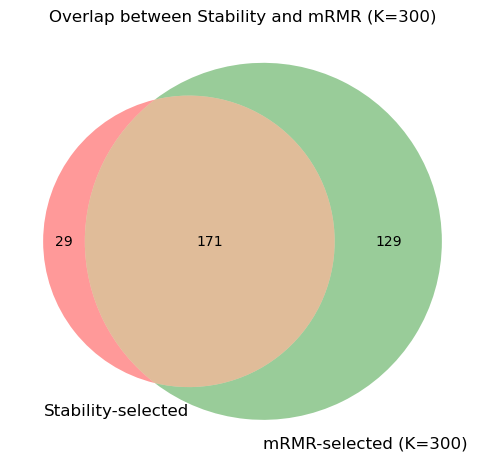

In [23]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

stable_set = set(stable_features)
mrmr_set = set(best_mrmr_features)

plt.figure(figsize=(6,6))
venn2(
    subsets=(stable_set, mrmr_set),
    set_labels=("Stability-selected", f"mRMR-selected (K={K_best})")
)
plt.title(f"Overlap between Stability and mRMR (K={K_best})")
plt.show()

## Build the development feature matrices

In [24]:
X_train_fs = train_df[best_mrmr_features]
y_train_fs = train_df["age"]

X_val_fs = val_df[best_mrmr_features]
y_val_fs = val_df["age"]

## Define the preprocessing (numeric‑only)

In [ ]:

preprocess_fs = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

## Build the three model pipelines

In [27]:
pipe_elastic_fs = Pipeline([
    ("preprocess", preprocess_fs),
    ("model", ElasticNet(max_iter=5000))
])

pipe_svr_fs = Pipeline([
    ("preprocess", preprocess_fs),
    ("model", SVR())
])

pipe_bayes_fs = Pipeline([
    ("preprocess", preprocess_fs),
    ("model", BayesianRidge())
])

## Fit the models on the development set

In [28]:
pipe_elastic_fs.fit(X_train_fs, y_train_fs)
pipe_svr_fs.fit(X_train_fs, y_train_fs)
pipe_bayes_fs.fit(X_train_fs, y_train_fs)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None


## Evaluate on the validation set (development split)

In [29]:
eval_elastic_fs = bootstrap_eval(pipe_elastic_fs, X_val_fs, y_val_fs)
eval_svr_fs = bootstrap_eval(pipe_svr_fs, X_val_fs, y_val_fs)
eval_bayes_fs = bootstrap_eval(pipe_bayes_fs, X_val_fs, y_val_fs)

## Build the Task 3 Feature‑Selection Table

In [30]:
table_elastic_fs = make_table("ElasticNet", "Feature Set (pre‑tuning)", eval_elastic_fs)
table_svr_fs = make_table("SVR", "Feature Set (pre‑tuning)", eval_svr_fs)
table_bayes_fs = make_table("BayesianRidge", "Feature Set (pre‑tuning)", eval_bayes_fs)

task3_fs_table = pd.concat(
    [table_elastic_fs, table_svr_fs, table_bayes_fs],
    ignore_index=True
)

task3_fs_table

,Model,Stage,RMSE (mean),95% CI,MAE,R2,Pearson r
0,ElasticNet,Feature Set (pre‑tuning),4.507502,"[3.76, 5.37]",3.483360,0.902368,0.952965
1,SVR,Feature Set (pre‑tuning),8.651338,"[6.87, 10.92]",6.224071,0.647051,0.857548
2,BayesianRidge,Feature Set (pre‑tuning),3.958298,"[3.33, 4.61]",3.024565,0.924533,0.962365


## Build the three model pipelines

# Hyperparameter Tuning (Task 4)

## Build development & evaluation matrices

In [ ]:
X_dev = dev_df[best_mrmr_features]
y_dev = dev_df["age"]

X_eval = eval_df[best_mrmr_features]
y_eval = eval_df["age"]

## Preprocessing Pipeline

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

## Define Model Pipelines

In [ ]:
pipe_elastic = Pipeline([
    ("preprocess", preprocess),
    ("model", ElasticNet(max_iter=5000))
])

pipe_svr = Pipeline([
    ("preprocess", preprocess),
    ("model", SVR())
])

pipe_bayes = Pipeline([
    ("preprocess", preprocess),
    ("model", BayesianRidge())
])

## Define Search Spaces

In [ ]:
from scipy.stats import loguniform, uniform

param_elastic = {
    "model__alpha": loguniform(0.001, 10),
    "model__l1_ratio": uniform(0.1, 1.0)
}

param_svr = {
    "model__C": loguniform(0.1, 500),
    "model__epsilon": [0.01, 0.1, 0.5, 1.0],
    "model__kernel": ["rbf", "linear"]
}

param_bayes = {
    "model__alpha_1": loguniform(1e-7, 1e-3),
    "model__alpha_2": loguniform(1e-7, 1e-3),
    "model__lambda_1": loguniform(1e-7, 1e-3),
    "model__lambda_2": loguniform(1e-7, 1e-3)
}

## Run Hyperparameter Tuning

In [ ]:
# Uncomment to run tuning
# search_elastic = tune_model(pipe_elastic, param_elastic, X_dev, y_dev)
# search_svr = tune_model(pipe_svr, param_svr, X_dev, y_dev)
# search_bayes = tune_model(pipe_bayes, param_bayes, X_dev, y_dev)

# best_elastic = search_elastic.best_estimator_
# best_svr = search_svr.best_estimator_
# best_bayes = search_bayes.best_estimator_

## Load Saved Models

In [ ]:
best_elastic = joblib.load("../models/best_elastic.pkl")
best_svr = joblib.load("../models/best_svr.pkl")
best_bayes = joblib.load("../models/best_bayes.pkl")

## Predictions for Tuned Models

In [ ]:
pred_elastic = best_elastic.predict(X_eval)
pred_svr = best_svr.predict(X_eval)
pred_bayes = best_bayes.predict(X_eval)

## Bootstrap Distributions

In [ ]:
rmse_elastic, r2_elastic = bootstrap_distributions(y_eval.values, pred_elastic)
rmse_svr, r2_svr = bootstrap_distributions(y_eval.values, pred_svr)
rmse_bayes, r2_bayes = bootstrap_distributions(y_eval.values, pred_bayes)

## Boxplots for Tuned Models

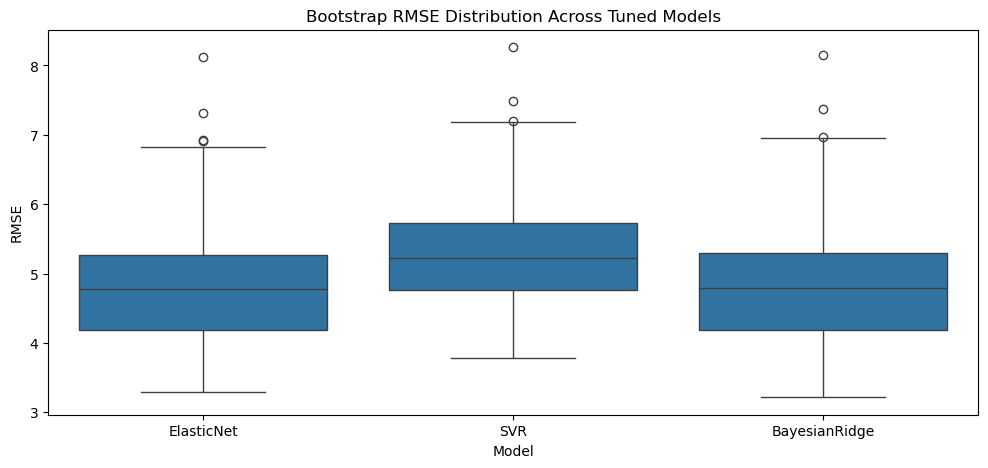

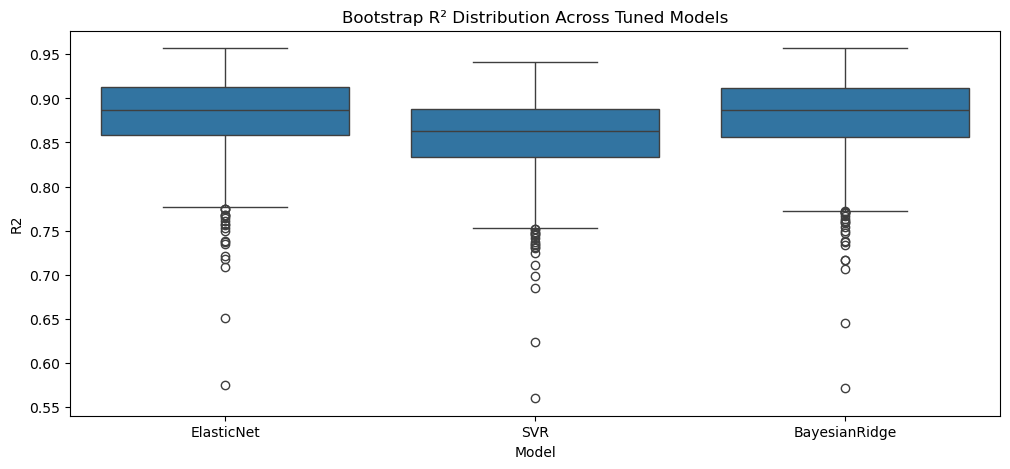

In [ ]:
df_boot = pd.DataFrame({
    "RMSE": np.concatenate([rmse_elastic, rmse_svr, rmse_bayes]),
    "R2":   np.concatenate([r2_elastic, r2_svr, r2_bayes]),
    "Model": (
        ["ElasticNet"] * len(rmse_elastic) +
        ["SVR"] * len(rmse_svr) +
        ["BayesianRidge"] * len(rmse_bayes)
    )
})

plt.figure(figsize=(12,5))
sns.boxplot(data=df_boot, x="Model", y="RMSE")
plt.title("Bootstrap RMSE Distribution Across Tuned Models")
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(data=df_boot, x="Model", y="R2")
plt.title("Bootstrap R² Distribution Across Tuned Models")
plt.show()

## Predicted vs Actual Scatterplots

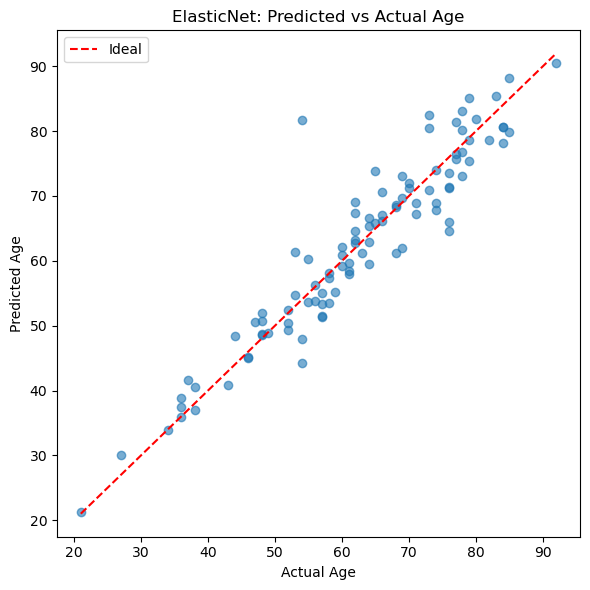

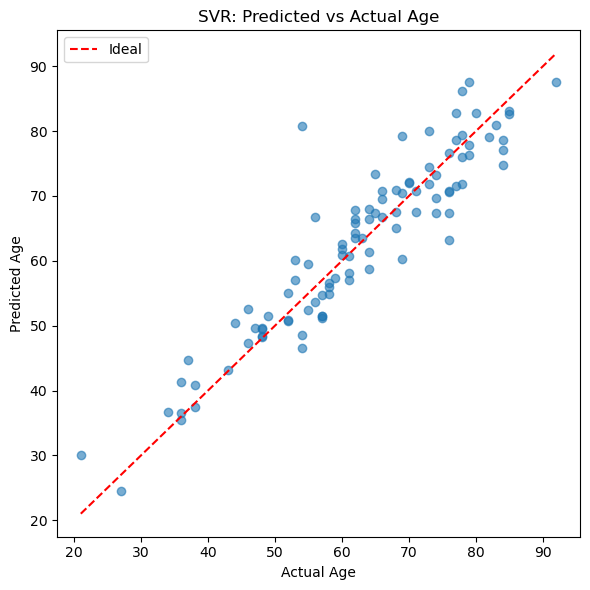

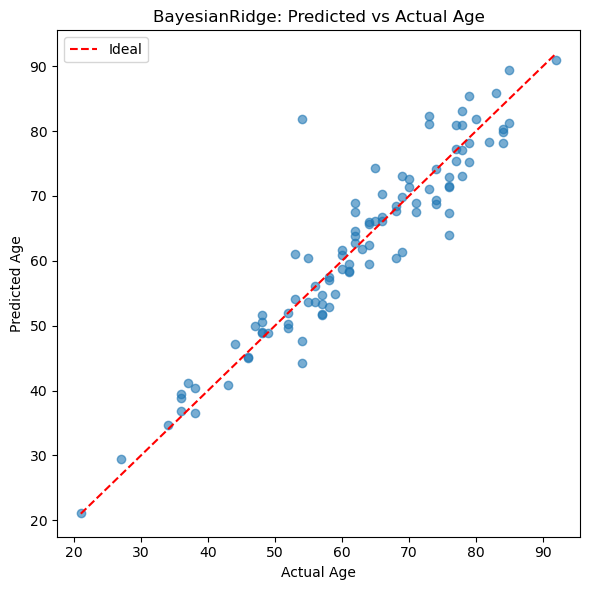

In [ ]:
models = {
    "ElasticNet": best_elastic,
    "SVR": best_svr,
    "BayesianRidge": best_bayes
}

for name, model in models.items():
    preds = model.predict(X_eval)

    plt.figure(figsize=(6,6))
    plt.scatter(y_eval, preds, alpha=0.6)
    plt.plot([y_eval.min(), y_eval.max()],
             [y_eval.min(), y_eval.max()],
             'r--', label="Ideal")

    plt.xlabel("Actual Age")
    plt.ylabel("Predicted Age")
    plt.title(f"{name}: Predicted vs Actual Age")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Final Evaluation Tables

In [ ]:
eval_elastic = bootstrap_eval(best_elastic, X_eval, y_eval)
eval_svr = bootstrap_eval(best_svr, X_eval, y_eval)
eval_bayes = bootstrap_eval(best_bayes, X_eval, y_eval)

table_elastic = make_table("ElasticNet", "FS+Tuned", eval_elastic)
table_svr = make_table("SVR", "FS+Tuned", eval_svr)
table_bayes = make_table("BayesianRidge", "FS+Tuned", eval_bayes)

final_table = pd.concat([table_elastic, table_svr, table_bayes], ignore_index=True)
final_table

,Model,Stage,RMSE (mean),95% CI,MAE,R2,Pearson r
0,ElasticNet,FS+Tuned,4.787117,"[3.58, 6.38]",3.352251,0.881636,0.941538
1,SVR,FS+Tuned,5.301679,"[4.20, 6.74]",3.947483,0.855270,0.927041
2,BayesianRidge,FS+Tuned,4.804907,"[3.52, 6.49]",3.392953,0.878347,0.940341


## Save Best Model

In [ ]:
joblib.dump(best_bayes, "../models/best_model.pkl")

['../models/best_model.pkl']